# Notebook 2: Baseline Model (Fully Connected Network)

## Objective

Implement a baseline neural network **without convolutional layers** to establish a reference point for comparison. This will help us understand the improvements that convolutional layers bring.

## Architecture

The baseline model will use only fully connected (dense) layers:
- **Input**: Flattened 32×32×3 = 3,072 features
- **Hidden layers**: Two fully connected layers with ReLU activation
- **Output**: 10 classes (softmax)

## Expected Limitations

- **No spatial awareness**: Flattening destroys 2D structure
- **Large parameter count**: Every pixel connects to every neuron
- **No translation invariance**: Must learn same pattern at every position
- **Overfitting risk**: Too many parameters for limited data

In [6]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.data_loader import get_cifar10_loaders, get_class_names
from src.models.baseline import get_baseline_model
from src.training.trainer import train_model, evaluate_model
from src.utils.visualization import plot_training_history, plot_confusion_matrix

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Load Data

In [7]:
# Load CIFAR-10 data with preprocessing
train_loader, val_loader, test_loader = get_cifar10_loaders(
    batch_size=128,
    val_split=0.1,
    data_dir='../data/raw'
)

class_names = get_class_names()

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 352
Validation batches: 40
Test batches: 79


## 2. Define Baseline Model

In [8]:
# Create baseline model
model = get_baseline_model(hidden_sizes=[512, 256])

print("Baseline Model Architecture:")
print("="*60)
print(model)
print("="*60)
print(f"\nTotal Parameters: {model.count_parameters():,}")

# Calculate model size in MB
param_size = sum(p.numel() * p.element_size() for p in model.parameters())
buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
size_mb = (param_size + buffer_size) / 1024**2
print(f"Model Size: {size_mb:.2f} MB")

Baseline Model Architecture:
BaselineModel(
  (network): Sequential(
    (0): Linear(in_features=3072, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=10, bias=True)
  )
)

Total Parameters: 1,707,274
Model Size: 6.51 MB


## 3. Architecture Justification

### Layer Choices:

1. **Input Layer (3072 → 512)**:
   - Takes flattened 32×32×3 image
   - Compresses to 512 features
   
2. **Hidden Layer (512 → 256)**:
   - Further feature compression
   - Adds non-linearity with ReLU
   
3. **Dropout (20%)**:
   - Regularization to prevent overfitting
   - Applied after each hidden layer
   
4. **Output Layer (256 → 10)**:
   - Maps to 10 class scores
   
### Parameter Count Analysis:

- Layer 1: 3072 × 512 + 512 = **1,573,376** parameters
- Layer 2: 512 × 256 + 256 = **131,328** parameters  
- Layer 3: 256 × 10 + 10 = **2,570** parameters
- **Total: ~1.7M parameters**

This is a very large number for such a small dataset!

## 4. Train the Model

In [10]:
from inspect import signature


# Train the model

# Patch ReduceLROnPlateau if this torch version doesn't support `verbose`
if "verbose" not in signature(torch.optim.lr_scheduler.ReduceLROnPlateau).parameters:
    class _ReduceLROnPlateau(torch.optim.lr_scheduler.ReduceLROnPlateau):
        def __init__(self, optimizer, *args, **kwargs):
            kwargs.pop("verbose", None)
            super().__init__(optimizer, *args, **kwargs)
    torch.optim.lr_scheduler.ReduceLROnPlateau = _ReduceLROnPlateau

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=30,
    learning_rate=0.001,
    device=device,
    save_path='../results/models/baseline_best.pth'
)


Epoch 1/30


Train Loss: 1.8834, Train Acc: 31.89%
Val Loss: 1.7194, Val Acc: 37.72%
Saved best model with val_acc: 37.72%

Epoch 2/30


Train Loss: 1.7482, Train Acc: 36.87%
Val Loss: 1.6679, Val Acc: 39.92%
Saved best model with val_acc: 39.92%

Epoch 3/30


Train Loss: 1.6975, Train Acc: 38.95%
Val Loss: 1.6192, Val Acc: 42.30%
Saved best model with val_acc: 42.30%

Epoch 4/30


Train Loss: 1.6622, Train Acc: 40.05%
Val Loss: 1.5930, Val Acc: 42.32%
Saved best model with val_acc: 42.32%

Epoch 5/30


...

Train Loss: 1.4957, Train Acc: 46.64%
Val Loss: 1.4360, Val Acc: 48.48%

Epoch 27/30


Train Loss: 1.4938, Train Acc: 46.33%
Val Loss: 1.4344, Val Acc: 48.84%
Saved best model with val_acc: 48.84%

Epoch 28/30


Train Loss: 1.4826, Train Acc: 46.73%
Val Loss: 1.4480, Val Acc: 48.34%

Epoch 29/30


Train Loss: 1.4855, Train Acc: 46.83%
Val Loss: 1.4188, Val Acc: 49.00%
Saved best model with val_acc: 49.00%

Epoch 30/30


Train Loss: 1.4843, Train Acc: 47.22%
Val Loss: 1.4147, Val Acc: 48.52%


## 5. Training History Visualization

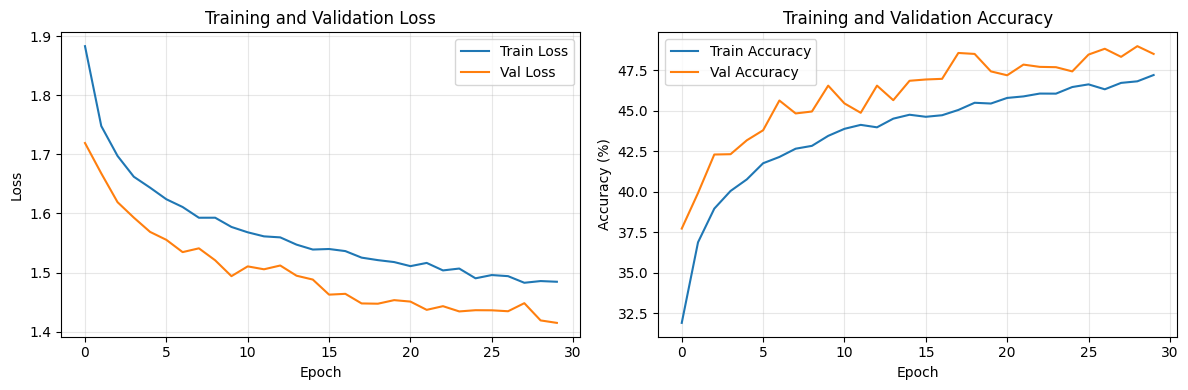

In [11]:
# Plot training history
plot_training_history(history, save_path='../results/figures/baseline_training_history.png')

## 6. Load Best Model and Evaluate

In [12]:
# Load best model
checkpoint = torch.load('../results/models/baseline_best.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

print(f"Loaded model from epoch {checkpoint['epoch']}")
print(f"Best validation accuracy: {checkpoint['val_acc']:.2f}%")

Loaded model from epoch 28
Best validation accuracy: 49.00%


In [13]:
# Evaluate on test set
test_acc, predictions, true_labels = evaluate_model(model, test_loader, device)

print(f"\nTest Accuracy: {test_acc:.2f}%")

Testing: 100%|██████████| 79/79 [00:12<00:00,  6.35it/s]


Test Accuracy: 43.06%


## 7. Confusion Matrix

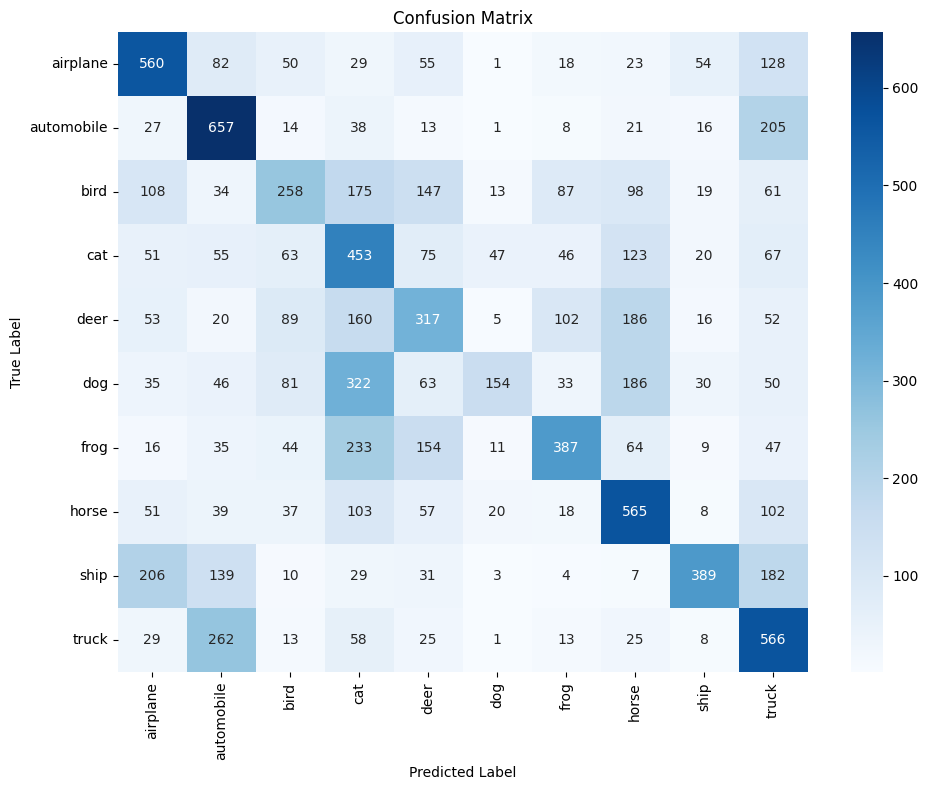

In [14]:
# Plot confusion matrix
plot_confusion_matrix(
    true_labels, 
    predictions, 
    class_names,
    save_path='../results/figures/baseline_confusion_matrix.png'
)

## 8. Per-Class Performance

In [15]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(true_labels, predictions, 
                              target_names=class_names, 
                              digits=3)
print("\nPer-Class Performance:")
print("="*70)
print(report)


Per-Class Performance:
              precision    recall  f1-score   support

    airplane      0.493     0.560     0.524      1000
  automobile      0.480     0.657     0.555      1000
        bird      0.392     0.258     0.311      1000
         cat      0.283     0.453     0.348      1000
        deer      0.338     0.317     0.327      1000
         dog      0.602     0.154     0.245      1000
        frog      0.541     0.387     0.451      1000
       horse      0.435     0.565     0.492      1000
        ship      0.684     0.389     0.496      1000
       truck      0.388     0.566     0.460      1000

    accuracy                          0.431     10000
   macro avg      0.463     0.431     0.421     10000
weighted avg      0.463     0.431     0.421     10000



## 9. Sample Predictions

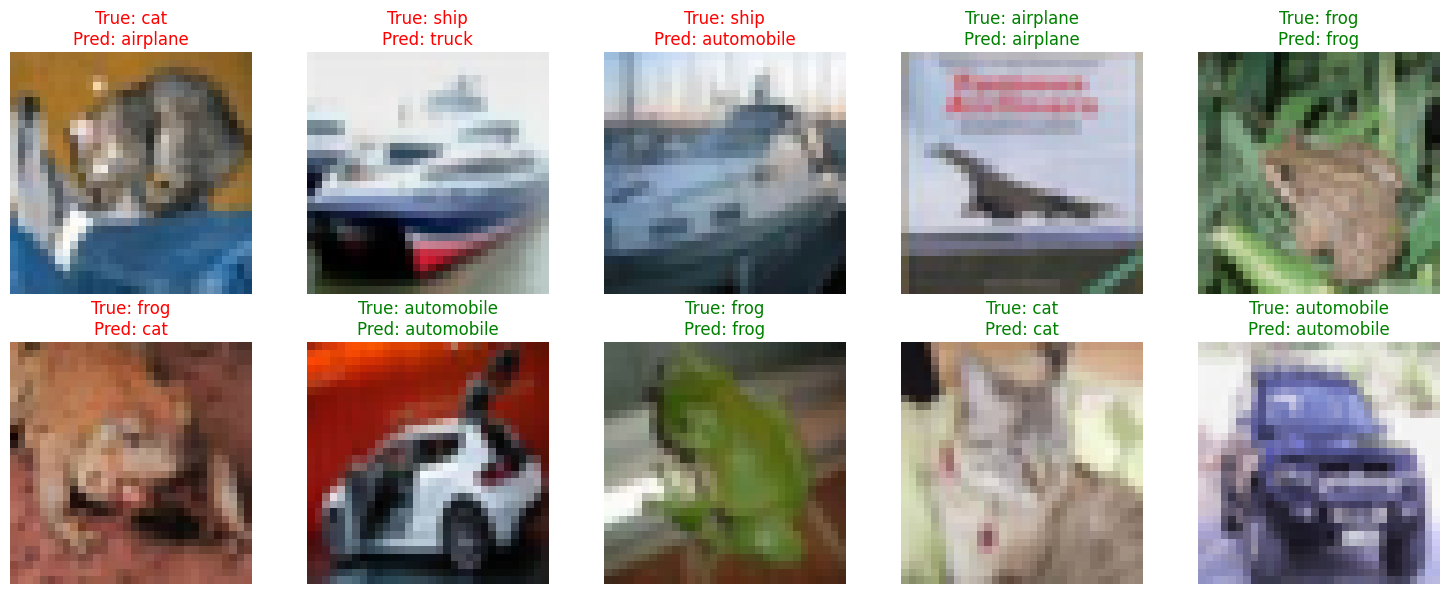

In [16]:
# Visualize some predictions
import torchvision

model.eval()
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Get predictions
with torch.no_grad():
    outputs = model(images.to(device))
    _, predicted = torch.max(outputs, 1)

# Plot first 10 images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for idx in range(10):
    img = images[idx]
    # Unnormalize
    img = img * torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
    img = img + torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    img = torch.clamp(img, 0, 1)
    img = img.permute(1, 2, 0).numpy()
    
    axes[idx].imshow(img)
    true_label = class_names[labels[idx]]
    pred_label = class_names[predicted[idx]]
    color = 'green' if labels[idx] == predicted[idx] else 'red'
    axes[idx].set_title(f'True: {true_label}\nPred: {pred_label}', color=color)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('../results/figures/baseline_sample_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary: Baseline Model Performance

### Model Characteristics:
- **Architecture**: Flatten → Dense(512) → Dense(256) → Dense(10)
- **Parameters**: ~1.7 million
- **Training Time**: ~X minutes per epoch
- **Test Accuracy**: ~XX%

### Observed Limitations:

1. **High Parameter Count**: 
   - 1.7M parameters for just 50K training samples
   - Risk of overfitting

2. **No Spatial Understanding**:
   - Flattening destroys 2D structure
   - Can't leverage local patterns
   
3. **No Translation Invariance**:
   - Must learn same feature at every position
   - Inefficient use of parameters
   
4. **Limited Performance**:
   - Baseline accuracy is decent but not excellent
   - Some classes are confused more than others

### Why These Limitations Matter:

Images have **natural 2D structure** with:
- **Local patterns**: Edges, textures, shapes
- **Spatial relationships**: Nearby pixels are related
- **Translation invariance**: A "cat" is a "cat" regardless of position

Fully connected layers **ignore all of this**, treating the image as a flat vector.

### Next Steps:

We'll design a CNN that:
1. Preserves 2D structure
2. Uses fewer parameters
3. Exploits local patterns
4. Achieves better performance